## Handling Images
Image classification is one of the most exciting areas of machine learning. The ability of computers to recognize patterns and objects from images is an incredibly powerful tool in our toolkit. However, before we can apply machine learning to images, we often first need to transform the raw images to features usable by our learning algorithms.

In [2]:
!pip install opencv-python

## OpenCV
To work with images, we will use the Open Source Computer Vision Library (OpenCV). While there are a number of good libraries out there, OpenCV is the most popular and documented library for handling images. One of the biggest hur-dles to using OpenCV is installing it. However, fortunately if we are using Python 3 (at the time of publication OpenCV does not work with Python 3.6+), we can use Anaconda’s package manager tool conda to install OpenCV in a single line of code in our terminal:
conda install --channel https://conda.anaconda.org/menpo opencv3
Afterward, we can check the installation by opening a notebook, importing OpenCV, and checking the version number (3.1.0):
import cv2
cv2. version 


## Loading Images
Problem
You want to load an image for preprocessing.
Solution
Use OpenCV’s imread.
Fundamentally, images are data and when we use imread we convert that data into a data type we are very familiar with—a NumPy array.
We have transformed the image into a matrix whose elements correspond to individ-ual pixels. We can even take a look at the actual values of the matrix:


In [1]:
# Load library

import cv2
import numpy as np
from matplotlib import pyplot as plt
# Load image as grayscale
image = cv2.imread("/Users/rukku/Downloads/golden-retriever-tongue-out.jpj", cv2.IMREAD_GRAYSCALE)
height, width = image.shape[:2]
print(f"Width: {width}, Height: {height}")


Width: 710, Height: 430


Grayscale = 2D array (pixel intensities)
A grayscale image contains only shades of gray, no color.
Each pixel has one value representing its intensity:
0 → black
255 → white
Values in between → different shades of gray
Because there’s only one value per pixel, the image is stored as a 2D array (matrix)

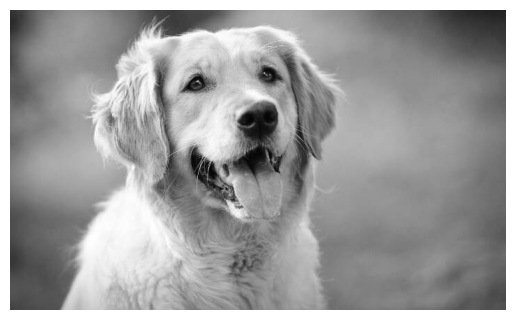

In [6]:
# If we want to view the image, we can use the Python plotting library Matplotlib:
# Show image
plt.imshow(image, cmap="gray")
plt.axis("off")
plt.show()


In [7]:
# Show data type
type(image) 


numpy.ndarray

In [8]:
# Show image data
image


array([[56, 56, 55, ..., 35, 35, 35],
       [55, 55, 55, ..., 35, 35, 35],
       [54, 54, 54, ..., 35, 35, 35],
       ...,
       [65, 65, 66, ..., 80, 80, 79],
       [64, 65, 65, ..., 80, 79, 79],
       [64, 64, 65, ..., 79, 79, 78]], shape=(430, 710), dtype=uint8)

What does each element in the matrix actually represent? In grayscale images, the value of an individual element is the pixel intensity. Intensity values range from black
(0) to white (255). 

In [9]:
#The resolution of our image was Width: 3628, Height: 5442, the exact dimensions of our matrix:
# Show dimensions
image.shape 

(430, 710)

In [10]:
# Show first pixel
image[0,0] 


np.uint8(56)

Color = 3D array (BGR)
Color images have three channels: Blue, Green, Red (BGR) in OpenCV.
Each pixel has three values [B, G, R] that mix to form the final color.
The image is stored as a 3D array:
First dimension: height
Second dimension: width
Third dimension: color channels

In [12]:
# In the matrix, each element contains three values corresponding to blue, green, red values (BGR):
# Load image in color
image_bgr = cv2.imread("/Users/rukku/Downloads/golden-retriever-tongue-out.jpj", cv2.IMREAD_COLOR)
# Show pixel
image_bgr[0,0]


array([17, 64, 56], dtype=uint8)

OpenCV loads color images in BGR order, but most visualization libraries like Matplotlib expect RGB order.
If we display BGR in Matplotlib without conversion, the colors will look wrong (e.g., blue and red swapped).

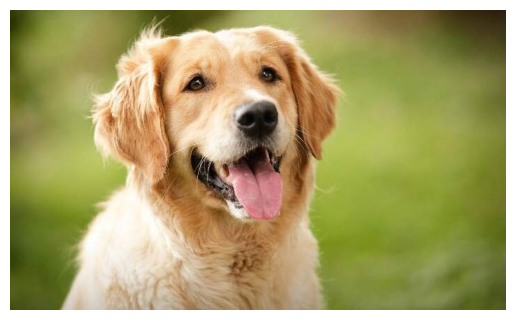

In [13]:
# Convert to RGB
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
# Show image
plt.imshow(image_rgb)
plt.axis("off") 
plt.show()


## Saving Images:
Problem
You want to save an image for preprocessing.
Solution
Use OpenCV’s imwrite
OpenCV’s imwrite saves images to the filepath specified. The format of the image is defined by the filename’s extension (.jpg, .png, etc.). One behavior to be careful about: imwrite will overwrite existing files without outputting an error or asking for confir-mation.

In [23]:
image = cv2.imread(
    "/Users/rukku/Downloads/golden-retriever-tongue-out.jpj",
    cv2.IMREAD_GRAYSCALE
)

print(image)

print(image is None)
print(type(image))
print(image.shape)

success = cv2.imwrite("new_image.jpg", image)
print(success)

import os
print(os.getcwd())

[[56 56 55 ... 35 35 35]
 [55 55 55 ... 35 35 35]
 [54 54 54 ... 35 35 35]
 ...
 [65 65 66 ... 80 80 79]
 [64 65 65 ... 80 79 79]
 [64 64 65 ... 79 79 78]]
False
<class 'numpy.ndarray'>
(430, 710)
True
/Users/rukku/Downloads


In [26]:
import cv2

image = cv2.imread(
    "golden-retriever-tongue-out.jpg",
    cv2.IMREAD_GRAYSCALE
)

success = cv2.imwrite(
    "new_image.jpg",
    image
)

print(success)

[ WARN:0@1545.121] global loadsave.cpp:278 findDecoder imread_('golden-retriever-tongue-out.jpg'): can't open/read file: check file path/integrity


error: OpenCV(4.13.0) /Users/xperience/GHA-OpenCV-Python/_work/opencv-python/opencv-python/opencv/modules/imgcodecs/src/loadsave.cpp:1193: error: (-215:Assertion failed) !_img.empty() in function 'imwrite'


In [28]:
# Load libraries
import cv2
import numpy as np
from matplotlib import pyplot as plt
# Load image as grayscale
image = cv2.imread("/Users/rukku/Downloads/golden-retriever-tongue-out.jpj", cv2.IMREAD_GRAYSCALE)
# Save image
cv2.imwrite("/Users/rukku/Downloads/New_golden-retriever-tongue-out.jpeg", image) 

True

In [29]:
import cv2
print(cv2.__version__)

4.13.0


## Resizing Images
Problem
You want to resize an image for further preprocessing.
Solution
Use resize to change the size of an image
Resizing images is a common task in image preprocessing for two reasons. First, images come in all shapes and sizes, and to be usable as features, images must have the same dimensions. This standardization of image size does come with costs, how-ever; images are matrices of information and when we reduce the size of the image we are reducing the size of that matrix and the information it contains. Second, machine learning can require thousands or hundreds of thousands of images. When those images are very large they can take up a lot of memory, and by resizing them we can dramatically reduce memory usage. Some common image sizes for machine learning are 32 × 32, 64 × 64, 96 × 96, and 256 × 256.

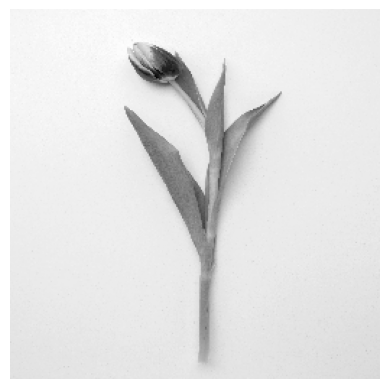

In [11]:
#Use resize to change the size of an image:
# Load image
import cv2
import numpy as np
from matplotlib import pyplot as plt
# Load image as grayscale
image = cv2.imread("flower.jpg", cv2.IMREAD_GRAYSCALE)
# Resize image to 256 pixels by 256 pixels
image_256x256 = cv2.resize(image, (256, 256))
# View image
plt.imshow(image_256x256, cmap="gray")
plt.axis("off") 
plt.show()


## Cropping Images
Problem
You want to remove the outer portion of the image to change its dimensions.
 
Solution
The image is encoded as a two-dimensional NumPy array, so we can crop the image easily by slicing the array.
Since OpenCV represents images as a matrix of elements, by selecting the rows and columns we want to keep we are able to easily crop the image. Cropping can be par-ticularly useful if we know that we only want to keep a certain part of every image.
 
For example, if our images come from a stationary security camera we can crop all the images so they only contain the area of interest.


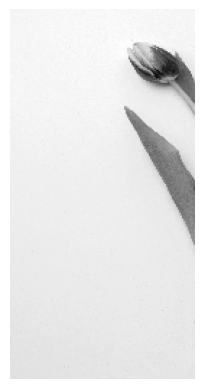

In [12]:
# Select first half of the columns and all rows
image_cropped = image_256x256[:,:128]
# Show image
plt.imshow(image_cropped, cmap="gray")
plt.axis("off")
plt.show()


## Blurring Images
Problem
You want to smooth out an image.
Solution
To blur an image, each pixel is transformed to be the average value of its neighbors. This neighbor and the operation performed are mathematically represented as a ker-nel (don’t worry if you don’t know what a kernel is). The size of this kernel determines the amount of blurring, with larger kernels producing smoother images. Here we blur an image by averaging the values of a 5 × 5 kernel around each pixel:

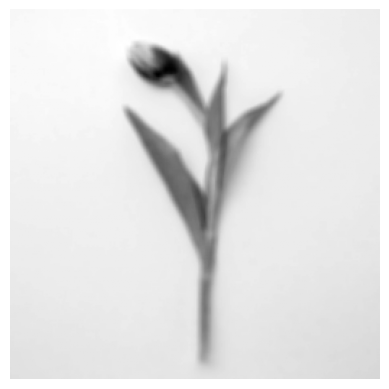

In [13]:
# Blur image
image_blurry = cv2.blur(image_256x256, (5,5))
# Show image
plt.imshow(image_blurry, cmap="gray")
plt.axis("off") 
plt.show()

## Creating Features for Machine Learning
Problem
You want to convert an image into an observation for machine learning.
Solution
Use NumPy’s flatten to convert the multidimensional array containing an image’s data into a vector containing the observation’s values:


In [14]:
# Load image
# Resize image to 10 pixels by 10 pixels
image_10x10 = cv2.resize(image_256x256, (10, 10))
# Convert image data to one-dimensional vector
image_10x10.flatten()


array([236, 238, 239, 233, 236, 236, 234, 231, 229, 228, 238, 234, 240,
       192,  79, 234, 233, 232, 230, 229, 236, 235, 237, 231, 226, 149,
       226, 229, 230, 229, 233, 231, 233, 212, 226, 147, 193, 228, 228,
       227, 231, 230, 230, 228, 139, 183, 221, 227, 228, 226, 229, 224,
       230, 228, 214, 150, 226, 228, 227, 224, 228, 228, 228, 228, 220,
       131, 227, 226, 226, 223, 225, 227, 228, 227, 226, 198, 226, 225,
       222, 221, 222, 225, 225, 226, 223, 198, 223, 223, 218, 218, 220,
       221, 222, 223, 222, 206, 224, 220, 217, 216], dtype=uint8)

In [15]:
# Load image in color
image_color = cv2.imread("flower.jpg", cv2.IMREAD_COLOR)
# Resize image to 10 pixels by 10 pixels
image_color_10x10 = cv2.resize(image_color, (10, 10))
 
# Convert image data to one-dimensional vector, show dimensions
image_color_10x10.flatten().shape 

(300,)

In [16]:
# Load image in grayscale
image_gray = cv2.imread("flower.jpg", cv2.IMREAD_GRAYSCALE)
# Convert image data to one-dimensional vector, show dimensions
image_gray.flatten().shape 

(19743576,)

In [17]:
# Load image in color
image_color = cv2.imread("flower.jpg", cv2.IMREAD_COLOR)
# Convert image data to one-dimensional vector, show dimensions
image_color.flatten().shape 

(59230728,)

## Encoding Mean Color as a Feature
Problem
You want a feature based on the colors of an image.
Solution
Each pixel in an image is represented by the combination of multiple color channels (often three: red, green, and blue). Calculate the mean red, green, and blue channel values for an image to make three color features representing the average colors in that image.
The output is three feature values for an observation, one for each color channel in the image. These features can be used like any other features in learning algorithms to classify images according to their colors.


In [24]:
# Load libraries
import cv2
import numpy as np
from matplotlib import pyplot as plt
# Load image as BGR
image_bgr = cv2.imread("flower.jpg", cv2.IMREAD_COLOR)
# Calculate the mean of each channel
channels = cv2.mean(image_bgr)
# Swap blue and red values (making it RGB, not BGR)
observation = np.array([(channels[2], channels[1], channels[0])])
# Show mean channel values
observation

array([[219.03704608, 220.67145045, 215.94577031]])

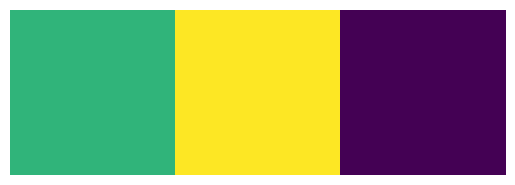

In [ ]:
# We can view the mean channel values directly:
# Show image
plt.imshow(observation)
plt.axis("off") 
plt.show()
